In [36]:
import pandas as pd
import numpy as np

In [37]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("zalando-research/fashionmnist")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\sande\.cache\kagglehub\datasets\zalando-research\fashionmnist\versions\4


In [38]:
import os
print("Print the directory", os.listdir(path))

Print the directory ['fashion-mnist_test.csv', 'fashion-mnist_train.csv', 't10k-images-idx3-ubyte', 't10k-labels-idx1-ubyte', 'train-images-idx3-ubyte', 'train-labels-idx1-ubyte']


In [39]:
data=os.listdir(path)

In [40]:
df=pd.read_csv(os.path.join(path,data[0]))

In [41]:
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,0,0,0,0,0,0,0,0,9,8,...,103,87,56,0,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0,...,34,0,0,0,0,0,0,0,0,0
2,2,0,0,0,0,0,0,14,53,99,...,0,0,0,0,63,53,31,0,0,0
3,2,0,0,0,0,0,0,0,0,0,...,137,126,140,0,133,224,222,56,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [42]:
df.shape

(10000, 785)

In [43]:
import matplotlib.pyplot as plt

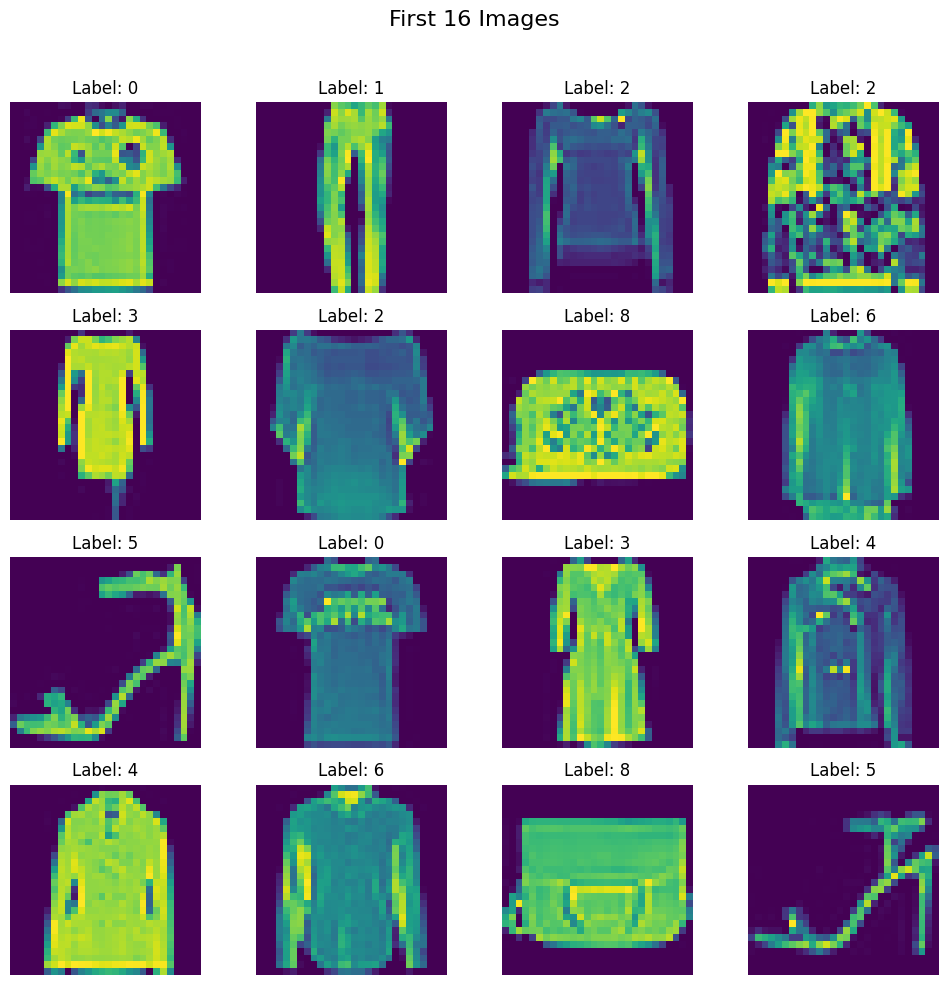

In [44]:
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
fig.suptitle("First 16 Images", fontsize=16)

# Plot the first 16 images from the dataset
for i, ax in enumerate(axes.flat):
    img = df.iloc[i, 1:].values.reshape(28, 28)  # Reshape to 28x28
    ax.imshow(img)  # Display in grayscale
    ax.axis('off')  # Remove axis for a cleaner look
    ax.set_title(f"Label: {df.iloc[i, 0]}")  # Show the label

plt.tight_layout(rect=[0, 0, 1, 0.96])  # Adjust layout to fit the title
plt.show()


In [45]:
#train test split
X=df.iloc[:,1:].values
y=df.iloc[:,0].values

In [46]:
from sklearn.model_selection import train_test_split

In [47]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [48]:
X_train.shape

(8000, 784)

In [49]:
X_train

array([[  0,   0,   0, ...,   0,   0,   0],
       [  0,   0,   0, ...,   0,   0,   0],
       [  0,   0,   0, ...,   0,   0,   0],
       ...,
       [  0,   0,   0, ...,   0,   0,   0],
       [  0,   0,   0, ..., 115,  35,   0],
       [  0,   0,   0, ...,   0,   0,   0]])

In [50]:
y_train

array([8, 5, 4, ..., 2, 9, 7])

In [51]:
X_train=X_train/255.0
X_test=X_test/255.0

In [52]:
import tensorflow
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense

In [53]:
model=Sequential()
model.add(Dense(128,activation='relu',input_shape=(784,)))
model.add(Dense(64,activation='relu'))
model.add(Dense(10,activation='softmax'))
model.compile(optimizer='sgd',loss='sparse_categorical_crossentropy',metrics=['accuracy'])
# model.fit(X_train,y_train,epochs=10)


d:\Programming\Deep_Learning_Concept\.tensorli\Lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [54]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [55]:
history=model.fit(
    X_train,
    y_train,
    epochs=10,
    validation_data=(X_test, y_test)
)

Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4141 - loss: 1.8155 - val_accuracy: 0.7095 - val_loss: 0.9215
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7098 - loss: 0.8671 - val_accuracy: 0.7575 - val_loss: 0.7248
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7557 - loss: 0.7269 - val_accuracy: 0.7835 - val_loss: 0.6528
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7839 - loss: 0.6367 - val_accuracy: 0.7985 - val_loss: 0.6048
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7952 - loss: 0.5912 - val_accuracy: 0.8045 - val_loss: 0.5689
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8069 - loss: 0.5682 - val_accuracy: 0.8035 - val_loss: 0.5785
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8124 - loss: 0.5383 - val_accuracy: 0.8205 - val_loss: 0.5266
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8300 - loss: 0.5025 - val_accuracy: 0.

In [56]:
model=Sequential()
model.add(Dense(128,activation='relu',input_shape=(784,)))
model.add(Dense(64,activation='relu'))
model.add(Dense(10,activation='softmax'))
model.compile(optimizer='rmsprop',loss='sparse_categorical_crossentropy',metrics=['accuracy'])
# model.fit(X_train,y_train,epochs=10)
history=model.fit(
    X_train,
    y_train,
    epochs=10,
    validation_data=(X_test, y_test)
)

Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6216 - loss: 1.0807 - val_accuracy: 0.8210 - val_loss: 0.5267
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8050 - loss: 0.5373 - val_accuracy: 0.8155 - val_loss: 0.5232
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8355 - loss: 0.4689 - val_accuracy: 0.8330 - val_loss: 0.4923
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8505 - loss: 0.4099 - val_accuracy: 0.8125 - val_loss: 0.4941
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8596 - loss: 0.3759 - val_accuracy: 0.8450 - val_loss: 0.4405
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8648 - loss: 0.3704 - val_accuracy: 0.8450 - val_loss: 0.4570
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8827 - loss: 0.3321 - val_accuracy: 0.8355 - val_loss: 0.4852
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8897 - loss: 0.3075 - val_accuracy: 0.

In [57]:
model=Sequential()
model.add(Dense(128,activation='relu',input_shape=(784,)))
model.add(Dense(64,activation='relu'))
model.add(Dense(10,activation='softmax'))
model.compile(optimizer='adagrad',loss='sparse_categorical_crossentropy',metrics=['accuracy'])
# model.fit(X_train,y_train,epochs=10)
history=model.fit(
    X_train,
    y_train,
    epochs=10,
    validation_data=(X_test, y_test)
)

Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.2459 - loss: 2.1355 - val_accuracy: 0.5900 - val_loss: 1.5766
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5990 - loss: 1.4923 - val_accuracy: 0.6680 - val_loss: 1.2317
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6588 - loss: 1.1984 - val_accuracy: 0.6875 - val_loss: 1.0533
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6714 - loss: 1.0464 - val_accuracy: 0.7005 - val_loss: 0.9508
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6883 - loss: 0.9471 - val_accuracy: 0.7120 - val_loss: 0.8862
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7093 - loss: 0.8810 - val_accuracy: 0.7270 - val_loss: 0.8361
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7247 - loss: 0.8235 - val_accuracy: 0.7360 - val_loss: 0.8037
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7321 - loss: 0.7983 - val_accuracy: 0.

In [58]:
model=Sequential()
model.add(Dense(128,activation='relu',input_shape=(784,)))
model.add(Dense(64,activation='relu'))
model.add(Dense(10,activation='softmax'))
model.compile(optimizer='adadelta',loss='sparse_categorical_crossentropy',metrics=['accuracy'])
# model.fit(X_train,y_train,epochs=10)
history=model.fit(
    X_train,
    y_train,
    epochs=10,
    validation_data=(X_test, y_test)
)

Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.0443 - loss: 2.4700 - val_accuracy: 0.0650 - val_loss: 2.4111
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.0799 - loss: 2.3857 - val_accuracy: 0.1150 - val_loss: 2.3355
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1235 - loss: 2.3152 - val_accuracy: 0.1640 - val_loss: 2.2731
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.1753 - loss: 2.2639 - val_accuracy: 0.2105 - val_loss: 2.2211
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2254 - loss: 2.2134 - val_accuracy: 0.2725 - val_loss: 2.1757
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2827 - loss: 2.1708 - val_accuracy: 0.3265 - val_loss: 2.1342
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3384 - loss: 2.1285 - val_accuracy: 0.3765 - val_loss: 2.0955
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.3816 - loss: 2.0910 - val_accuracy: 0.

In [59]:
history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

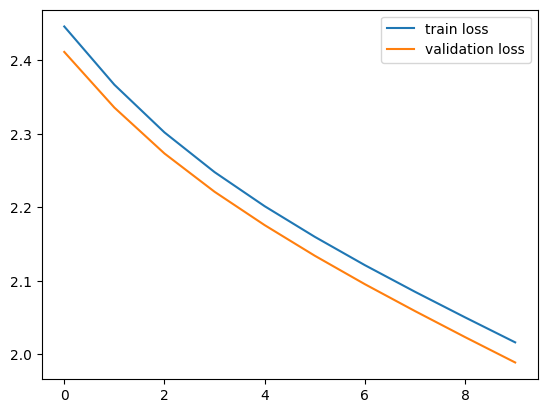

In [60]:
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='validation loss')
plt.legend()
plt.show()

### For Optimizer Find best 

In [61]:
import keras_tuner as kt

In [62]:
from tensorflow.python.distribute import values


def build_model(hp):
    model=Sequential()
    model.add(Dense(128,activation='relu',input_shape=(784,)))
    model.add(Dense(64,activation='relu'))
    model.add(Dense(10,activation='softmax'))

    hp_optimizer=hp.Choice('optimizer',values=['sgd','rmsprop','adagrad','adadelta','adam'])
    # hp_learning_rate=hp.Choice('learning_rate',[1e-2,1e-3,1e-4])  
    model.compile(optimizer=hp_optimizer,loss='sparse_categorical_crossentropy',metrics=['accuracy'])
    return model

In [63]:
tuner=kt.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=6,
    executions_per_trial=2,
    directory='my_dir',
    project_name='helloworld',
    overwrite=True,
)

In [64]:
tuner.search(X_train, y_train, epochs=5, validation_data=(X_test, y_test))

Trial 5 Complete [00h 00m 08s]
val_accuracy: 0.8492499887943268

Best val_accuracy So Far: 0.8492499887943268
Total elapsed time: 00h 00m 35s


In [65]:
tuner.get_best_hyperparameters()[0].values

{'optimizer': 'adam'}

In [66]:
tuner.get_best_models(num_models=1)[0]
model.summary()

d:\Programming\Deep_Learning_Concept\.tensorli\Lib\site-packages\keras\src\saving\saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 328,160 (1.25 MB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 218,774 (854.59 KB)

In [67]:
model.fit(X_train, y_train,epochs=100,batch_size=32,initial_epoch=6,validation_data=(X_test,y_test))

Epoch 7/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4661 - loss: 1.9949 - val_accuracy: 0.4900 - val_loss: 1.9560
Epoch 8/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4924 - loss: 1.9564 - val_accuracy: 0.5065 - val_loss: 1.9239
Epoch 9/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4954 - loss: 1.9325 - val_accuracy: 0.5155 - val_loss: 1.8927
Epoch 10/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5081 - loss: 1.8988 - val_accuracy: 0.5285 - val_loss: 1.8619
Epoch 11/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5177 - loss: 1.8735 - val_accuracy: 0.5365 - val_loss: 1.8319
Epoch 12/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5314 - loss: 1.8354 - val_accuracy: 0.5450 - val_loss: 1.8027
Epoch 13/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5274 - loss: 1.8153 - val_accuracy: 0.5505 - val_loss: 1.7742
Epoch 14/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5425 - loss: 1.7850 - val

#### No. of layers Find out

In [68]:
def build_model(hp):
    model=Sequential()
    units=hp.Int('units',min_value=32,max_value=512)
    model.add(Dense(units=units,activation='relu',input_shape=(784,)))
    model.add(Dense(64,activation='softmax'))
    model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])
    return model